# Лабораторная работа 5

# Анимация качения треугольника Рело по квадрату

*Радивилова Екатерина*, 24.04.2026

## Задание 5.1. Начальное положение треугольника Рело и квадрата

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
import relo
import matplotlib.animation as anim
%matplotlib inline

In [8]:
n = 3 # количество вершин треугольника Рело
center = np.array([0.,0.]) # центр треугольника Рело
r = 10 # ширина треугольника Рело
N = 100 # количество точек для описания стороны треугольника Рело

Для построения матрицы **relo_matrix** координат точек-границ треугольника Рело используем функцию **regular_polygon_Rel(n, center, r, N)** из модуля relo , созданного в Лабораторной работе 4

In [9]:
relo_matrix = relo.regular_polygon_Relo(r=r, center=center, N=N)


Длина стороны квадрата равна ширине треугольника Рело, центр квадрата располагаем в начале координат

Построим матрицу для квадрата, содержащую по **N_frames** точек для описания каждой границы Для этого сначала создадим массив из точек вершин, и в цикле пропишем им точки

In [10]:

vertexes = np.array([
    [-r/2, -r/2],
    [ r/2, -r/2],
    [ r/2,  r/2],
    [-r/2,  r/2],
    [-r/2, -r/2]
])
square_points = []

In [11]:

for i in range(4):
    start = vertexes[i]
    end = vertexes[i + 1]
    x_vals = np.linspace(start[0], end[0], N)
    y_vals = np.linspace(start[1], end[1], N)
    for x, y in zip(x_vals, y_vals):
        square_points.append([x, y])
square = np.array(square_points)

(np.float64(-5.500000000000002),
 np.float64(5.5),
 np.float64(-5.538675134594813),
 np.float64(6.312177826491069))

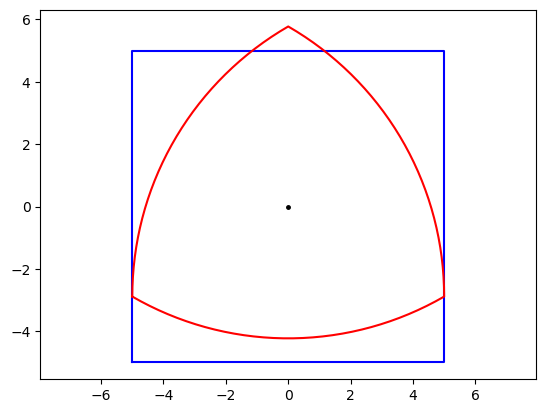

In [13]:

plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix[:,0],relo_matrix[:,1],'r-')
plt.plot(center[0],center[1],'k.',markersize=5)

plt.axis('equal')

Для определения величины **shift** отнимем от радиуса описанной окружности около треугольника со стороной **l=r** половину длины квадрата, т.е. **r/2**

In [14]:

shift=[r/(3**(1/2))-r/2,0]

In [15]:
relo_matrix_shifted = relo_matrix - shift
center -= shift

(np.float64(-6.312177826491073),
 np.float64(5.538675134594813),
 np.float64(-5.538675134594813),
 np.float64(6.312177826491069))

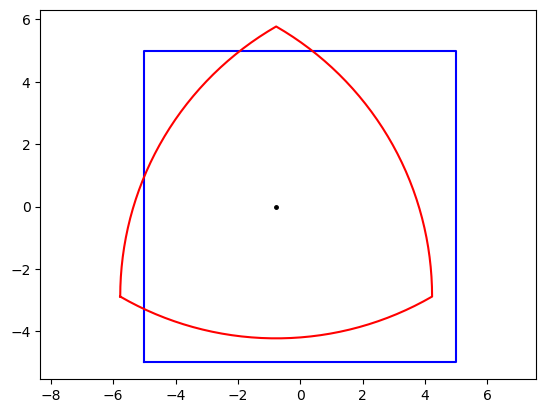

In [16]:
plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1],'r-')
plt.plot(center[0],center[1],'k.',markersize=5)
plt.axis('equal')

## Задание 5.2. Анимация поступательного движения треугольника Рело по окружности

Полагаем, что при качении треугольника Рело по квадрату против часовой стрелки центр треугольника Рело совершает поступательное движение по окружности с центром окружности в начале координат и радиусом, равным **shift[0]** , против часовой стрелки -
 до 
. Зададим количество кадров анимации **N_frames** , необходимое для поступательного движения треугольника с полным обходом окружности

In [17]:
N_frames = 100

Создадим матрицу **center_frame** из **Nframes** строк и двух столбцов для описания координат точек окружности, необходимой для реализации поступательного движения, с центром в начале координат и радиусом **shift[0]** при обходе окружности против часовой стрелки. В первом столбце матрицы расположены x-координаты точек, во втором столбце -- y-координаты.

In [18]:
t_center = np.linspace(-np.pi, np.pi, N_frames)
center_frame = shift[0]*np.transpose([np.cos(t_center), np.sin(t_center)])

In [19]:
frame = 0
relo_matrix_shifted = relo_matrix + center_frame[frame]

(np.float64(-6.312177826491073),
 np.float64(5.538675134594813),
 np.float64(-5.538675134594813),
 np.float64(6.312177826491069))

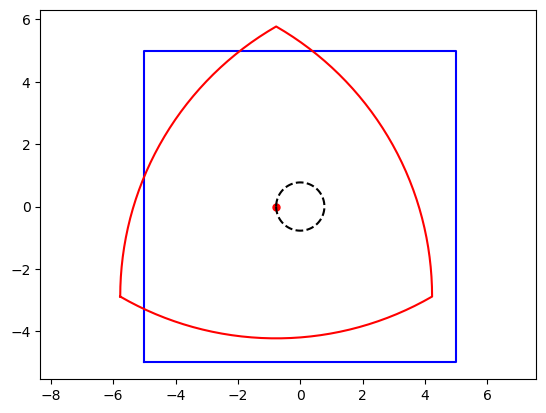

In [20]:
plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1],'r-')
plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
plt.plot(center_frame[:,0],center_frame[:,1],'k--')
plt.axis('equal')

Изобразим функцию трех аргументов **draw_frame(r, N_frames, frame)** , которая изображает кадр с номером **frame** при поступательном движении центра треугольника Рело по окружности против часовой стрелки.

In [21]:
def draw_frame(r, N_frames, frame=0):
    """
    Отрисовывает один кадр движения треугольника по окружности с заданным радиусом и числом кадров.

    Параметры:
    - r (int): Ширина треугольника Рело.
    - N_frames (int): Общее количество кадров анимации.
    - frame (int, по умолчанию 0): Номер кадра, который нужно отрисовать.

    Функция использует глобальные переменные:
    - square: Массив координат квадрата.
    - relo_matrix: Массив координат (N×2), представляющий вершины треугольника Рело, расположенного в началe координат.
    
    """
    shift=[r/(3**(1/2))-r/2,0]
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift[0]*np.transpose([np.cos(t_center), np.sin(t_center)])
    relo_matrix_shifted = relo_matrix + center_frame[frame]
    plt.plot(square[:,0],square[:,1],'b-')
    plt.plot(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1],'r-')
    plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
    plt.plot(center_frame[:,0],center_frame[:,1],'k--')
    plt.axis('equal')

Изобразим несколько кадров анимации, расположив их в одном графическом окне по горизонтали. Для этого используем функцию **subplot(m,n,k)** из модуля **pyplot** пакета **matplotlib** , которая позволяет расположить графики в виде таблицы из **m** строк, **n** столбцов на **k**-ой позиции при последовательной нумерации графиков слева-направо и сверху-вниз, начиная с 1.

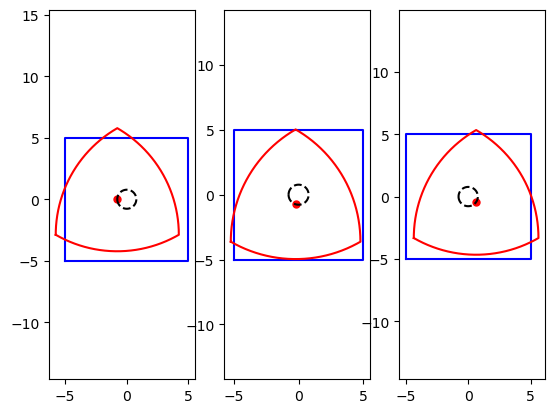

In [22]:
plt.figure()
N_frames = 100
plt.subplot(1,3,1)
draw_frame(r=r, N_frames=N_frames)
plt.subplot(1,3,2)
draw_frame(r=r, N_frames=N_frames, frame=20)
plt.subplot(1,3,3)
draw_frame(r=r, N_frames=N_frames, frame=40)

In [23]:
from matplotlib.animation import FuncAnimation

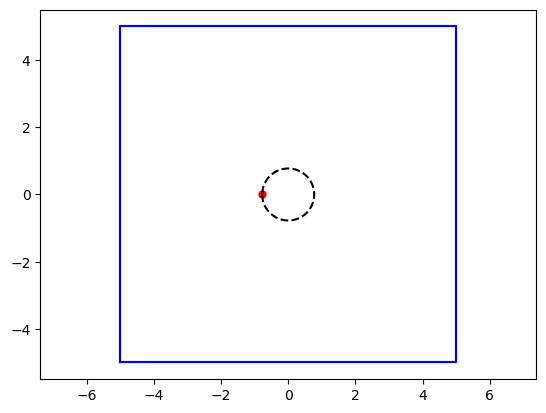

In [24]:
fig1=plt.figure()
ax1 = plt.axes()
plt.axis('equal')
line1, = ax1.plot(square[:,0],square[:,1],'b-') 
line2, = ax1.plot([], [],'go')
line3,=ax1.plot([],[],'r-')
def at_frame(point):
    line2.set_data([point[0]], [point[1]])
    relo_matrix_shifted = relo_matrix+point
    line3.set_data(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1])
def init():
    global line2
    line1, = ax1.plot(square[:,0],square[:,1],'b-') 
    line3,=ax1.plot([],[],'r-')
    line2, = ax1.plot([], [],'go') 
    line4,=ax1.plot(center_frame[0,0],center_frame[0,1],'r.',markersize=10)
    line5,=ax1.plot(center_frame[:,0],center_frame[:,1],'k--')
FuncAnimation(fig1, at_frame, frames=center_frame, init_func=init,repeat=False, interval=25)

## Задание 5.3. Анимация качения треугольника Рело

Дополнительно к поступательному движению треугольника Рело против часовой cтрелки добавим вращательное движение по часовой стрелке на угол theta . При этом будем учитывать, что полный оборот центра треугольника на угол $ 2\pi $
 соответствует вращению треугольника Рело на угол $2\pi/3$
. Определим пользовательскую функцию **rotate_matrix(theta)** для создания матрицы поворота по часовой стрелке на угол theta с применением синтаксиса **lambda**-функций

In [25]:

rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
 [-np.sin(theta), np.cos(theta)]])
rotate_matrix(np.pi)

array([[-1.0000000e+00,  1.2246468e-16],
       [-1.2246468e-16, -1.0000000e+00]])

Для поворота треугольника Рело на заданный угол необходимо матрицу поворота умножить на каждую точку в представлении треугольника Рело **relo_matrix** с центром в начале координат. Для умножения матрицы на вектор используем функцию **dot** из расширения numpy . Например, повернем треугольник Рело **relo_matrix** с центром в начале координат на угол $\pi/3$
 по часовой стрелке

In [26]:
theta = np.pi/3
matrix = rotate_matrix(theta)

In [28]:
relo_matrix_rotated = np.array([np.dot(matrix,row) for row in relo_matrix])

(np.float64(-5.500000000000002),
 np.float64(5.499999999999999),
 np.float64(-6.3508529610858835),
 np.float64(6.350852961085881))

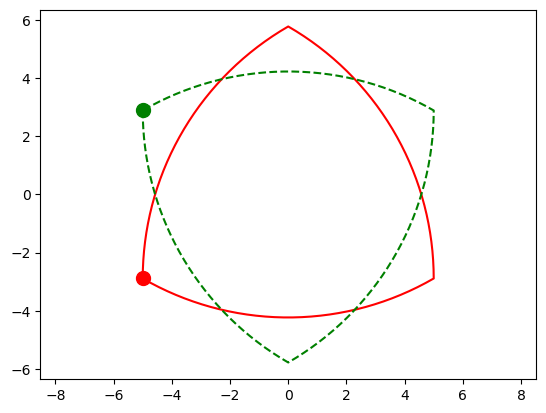

In [29]:
plt.figure()
plt.plot(relo_matrix[:,0],relo_matrix[:,1],'r-')
plt.plot(relo_matrix[0,0],relo_matrix[0,1],'r.',markersize=20)
plt.plot(relo_matrix_rotated[:,0],relo_matrix_rotated[:,1],'g--')
plt.plot(relo_matrix_rotated[0,0],relo_matrix_rotated[0,1],'g.',markersize=20)
plt.axis('equal')

Определим массив theta со значениями угла поворота при вращательном движении, согласованный с полным оборотом центра треугольника Рело за **N_frames** кадров.

In [30]:
theta = np.linspace(0, 2*np.pi/3, N_frames)

Для совмещения вращательного и поступательного движения треугольника Рело в кадре **frame** сначала будем поворачивать треугольник Рело с центром в начале координат на угол **theta[frame]** , затем будем перемещать треугольник Рело на вектор **center_frame[frame]**

Изобразим 20-ый кадр анимации качения треугольника Рело

(np.float64(-6.522747875731589),
 np.float64(5.548702279796743),
 np.float64(-5.997810765063615),
 np.float64(5.523705274526839))

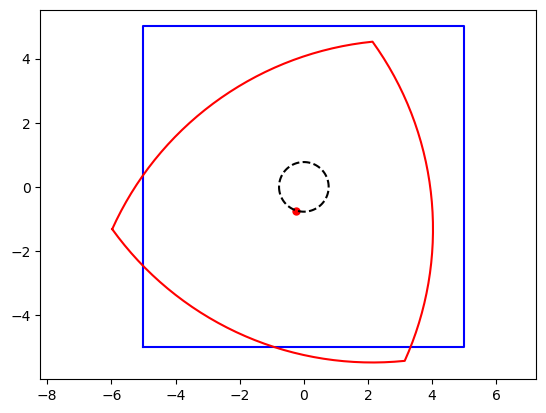

In [31]:
frame = 20
matrix = rotate_matrix(theta[frame])
relo_matrix_changed = (np.array([np.dot(matrix,row) for row in relo_matrix])
 + center_frame[frame])
plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix_changed[:,0],relo_matrix_changed[:,1],'r-')
plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
plt.plot(center_frame[:,0],center_frame[:,1],'k--')
plt.axis('equal')

In [32]:
def draw_frame(r, N_frames, frame=0):
    shift=[r/(3**(1/2))-r/2,0]
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift[0]*np.transpose([np.cos(t_center), np.sin(t_center)])
    theta = np.linspace(0, 2*np.pi/3, N_frames)
    matrix = rotate_matrix(theta[frame])
    relo_matrix_changed = (np.array([np.dot(matrix,row) for row in relo_matrix])
     + center_frame[frame])
    plt.plot(square[:,0],square[:,1],'b-')
    plt.plot(relo_matrix_changed[:,0],relo_matrix_changed[:,1],'r-')
    plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
    plt.plot(center_frame[:,0],center_frame[:,1],'k--')
    plt.axis('equal')

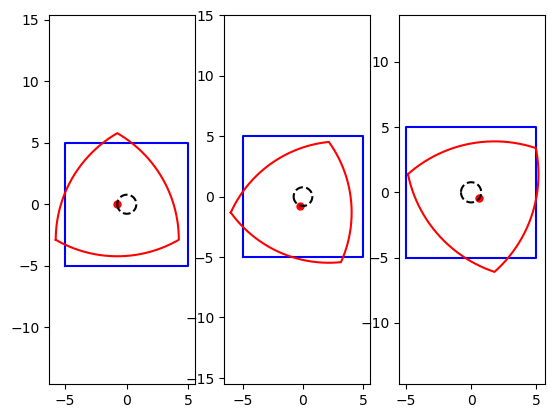

In [33]:
plt.figure()
plt.subplot(1,3,1)
draw_frame(r=r, N_frames=N_frames)
plt.subplot(1,3,2)
draw_frame(r=r, N_frames=N_frames, frame=20)
plt.subplot(1,3,3)
draw_frame(r=r, N_frames=N_frames, frame=40)

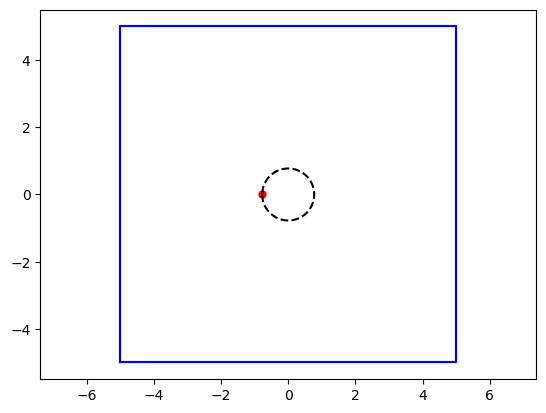

In [34]:
plt.close('all')
fig2=plt.figure()
ax2 = plt.axes()
plt.axis('equal')
line1, = ax2.plot(square[:,0],square[:,1],'b-') # объект для графика функции
line2, = ax2.plot([], [],'go') # объект для точки
line3,=ax2.plot([],[],'r-')
def at_frame2(frame):
    global center_frame
    point=center_frame[frame]
    line2.set_data([point[0]], [point[1]])
    matrix=rotate_matrix(theta[frame])
    relo_matrix_changed = (np.array([np.dot(matrix,row) for row in relo_matrix])
     + point)
    line3.set_data(relo_matrix_changed[:,0],relo_matrix_changed[:,1])
def init2():
    global line2
    global line3
    line1, = ax2.plot(square[:,0],square[:,1],'b-') # объект для графика функции
    line3,=ax2.plot([],[],'r-')
    line2, = ax2.plot([], [],'go') # объект для точки
    line4,=ax2.plot(center_frame[0,0],center_frame[0,1],'r.',markersize=10)
    line5,=ax2.plot(center_frame[:,0],center_frame[:,1],'k--')
FuncAnimation(fig2, at_frame2, frames=range(N_frames), init_func=init2,repeat=False, interval=20)

In [35]:
plt.close('all')